In [3]:
# pip install google-cloud-bigquery pandas pyarrow db-dtypes notebook ipykernel

In [4]:
from google.cloud import bigquery
import pandas as pd

c:\Users\ACER\AppData\Local\Programs\Python\Python313\Lib\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.5.0) or chardet (6.0.0.post1)/charset_normalizer (3.4.3) doesn't match a supported version!
  warnings.warn(


In [5]:
client = bigquery.Client(project="bi-project-2026")

c:\Users\ACER\AppData\Local\Programs\Python\Python313\Lib\site-packages\google\auth\_default.py:114: UserWarning: Your application has authenticated using end user credentials from Google Cloud SDK without a quota project. You might receive a "quota exceeded" or "API not enabled" error. See the following page for troubleshooting: https://cloud.google.com/docs/authentication/adc-troubleshooting/user-creds. 
  warnings.warn(_CLOUD_SDK_CREDENTIALS_WARNING)


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [7]:
query = """
SELECT *
FROM `bi-project-2026.analytics.dim_customers`
LIMIT 100
"""
dim_customers = client.query(query).to_dataframe()
dim_customers

,customer_sk,customer_id,customer_name,city,run_id,load_time,is_current
0,44ec9f4e-0034-4ae7-9768-0e20e756398c,789421,Lotus Mart,Ahmedabad,manual__2026-03-24T16:07:06.924582+00:00,2026-03-24 16:08:06.378886+00:00,True
1,8894ef37-1f10-4f5d-9353-355a599418cf,789221,Atlas Stores,Ahmedabad,manual__2026-03-24T16:07:06.924582+00:00,2026-03-24 16:08:06.378886+00:00,True
2,c6b7a4ea-b3ec-432f-8f42-9200f48ab04d,789702,Sorefoz Mart,Ahmedabad,manual__2026-03-24T16:07:06.924582+00:00,2026-03-24 16:08:06.378886+00:00,True
3,1d4607da-f3d7-4e31-8e1f-f5a39f3516c5,789902,Elite Mart,Ahmedabad,manual__2026-03-24T16:07:06.924582+00:00,2026-03-24 16:08:06.378886+00:00,True
4,b984357d-6151-46ac-b717-ec86d6ab9087,789121,Coolblue,Ahmedabad,manual__2026-03-24T16:07:06.924582+00:00,2026-03-24 16:08:06.378886+00:00,True
5,3feb8914-b27c-46f5-a0b0-4c174ce3bbf7,789521,Acclaimed Stores,Ahmedabad,manual__2026-03-24T16:07:06.924582+00:00,2026-03-24 16:08:06.378886+00:00,True
6,d4eff9ca-b8f7-444c-964a-5aaa2aec05ed,789621,Expert Mart,Ahmedabad,manual__2026-03-24T16:07:06.924582+00:00,2026-03-24 16:08:06.378886+00:00,True
7,29671ac7-ef49-4b23-92e4-c1bca14ff146,789321,Chiptec Stores,Ahmedabad,manual__2026-03-24T16:07:06.924582+00:00,2026-03-24 16:08:06.378886+00:00,True
8,9270652c-17ab-4c8e-9692-ff483a813548,789102,Vijay Stores,Ahmedabad,manual__2026-03-24T16:07:06.924582+00:00,2026-03-24 16:08:06.378886+00:00,True
9,e557e332-eccc-49a8-9026-6709ec008dca,789721,Logic Stores,Ahmedabad,manual__2026-03-24T16:07:06.924582+00:00,2026-03-24 16:08:06.378886+00:00,True


In [8]:
query = """
SELECT *
FROM `bi-project-2026.analytics.dim_date`
LIMIT 100
"""
dim_date = client.query(query).to_dataframe()
dim_date

,date,mmm_yy,week_no
0,2022-05-09,May-22,19
1,2022-06-28,Jun-22,26
2,2022-04-03,Apr-22,13
3,2022-08-19,Aug-22,33
4,2022-05-06,May-22,18
...,...,...,...
95,2022-08-07,Aug-22,31
96,2022-08-23,Aug-22,34
97,2022-04-19,Apr-22,16
98,2022-05-19,May-22,20


In [9]:
query = """
SELECT *
FROM `bi-project-2026.analytics.dim_products`
LIMIT 100
"""
dim_products = client.query(query).to_dataframe()
dim_products

,product_sk,product_id,product_name,category,price,cost,run_id,load_time,is_current
0,c76e599e-a744-416c-98fc-eeea7d35c223,25891601,AM Tea 500,Beverages,17000.0,11000.0,manual__2026-03-24T16:07:06.924582+00:00,2026-03-24 16:08:06.449213+00:00,True
1,27f0067c-4ede-43b6-a609-f348c1cf93b4,25891602,AM Tea 250,Beverages,22000.0,18000.0,manual__2026-03-24T16:07:06.924582+00:00,2026-03-24 16:08:06.449213+00:00,True
2,0c8015f3-a660-4867-bf19-add0a4e400c8,25891603,AM Tea 100,Beverages,31000.0,19000.0,manual__2026-03-24T16:07:06.924582+00:00,2026-03-24 16:08:06.449213+00:00,True
3,f50f117a-87a9-45cc-862a-366ba3eba953,25891402,AM Curd 100,Dairy,52000.0,39000.0,manual__2026-03-24T16:07:06.924582+00:00,2026-03-24 16:08:06.449213+00:00,True
4,6d238649-b741-418c-b918-9eb03d03f3c6,25891301,AM Ghee 250,Dairy,56000.0,40000.0,manual__2026-03-24T16:07:06.924582+00:00,2026-03-24 16:08:06.449213+00:00,True
5,eed007f7-ee13-416d-bf38-f34380791940,25891202,AM Butter 250,Dairy,66000.0,51000.0,manual__2026-03-24T16:07:06.924582+00:00,2026-03-24 16:08:06.449213+00:00,True
6,3e4313fb-bec8-4126-9329-98cc1d44a222,25891203,AM Butter 500,Dairy,66000.0,57000.0,manual__2026-03-24T16:07:06.924582+00:00,2026-03-24 16:08:06.449213+00:00,True
7,d75b635c-96c7-4130-9086-8a39a64b9c56,25891101,AM Milk 500,Dairy,87000.0,71000.0,manual__2026-03-24T16:07:06.924582+00:00,2026-03-24 16:08:06.449213+00:00,True
8,7e54bc16-2610-41f2-b05c-da1720d9b075,25891201,AM Butter 100,Dairy,110000.0,95000.0,manual__2026-03-24T16:07:06.924582+00:00,2026-03-24 16:08:06.449213+00:00,True
9,48cefadb-cf96-49cf-bd00-15ec5d7c5837,25891303,AM Ghee 100,Dairy,110000.0,89000.0,manual__2026-03-24T16:07:06.924582+00:00,2026-03-24 16:08:06.449213+00:00,True


In [10]:
query = """
SELECT *
FROM `bi-project-2026.analytics.dim_targets_orders`
LIMIT 100
"""
dim_targets_orders = client.query(query).to_dataframe()
dim_targets_orders

,order_sk,customer_sk,customer_id,ontime_target,infull_target,otif_target,run_id,load_time,is_current
0,c5365722-a13c-402c-bd60-346103a51aa9,None,789122,0.76,0.65,0.49,manual__2026-03-24T16:07:06.924582+00:00,2026-03-24 16:08:15.842777+00:00,True
1,2400fef3-4c42-4682-a4e6-dcc3a1863772,None,789903,0.92,0.65,0.60,manual__2026-03-24T16:07:06.924582+00:00,2026-03-24 16:08:15.842777+00:00,True
2,d2bdd4b4-e6f4-4da5-b60d-31c2f990bbff,None,789421,0.78,0.66,0.51,manual__2026-03-24T16:07:06.924582+00:00,2026-03-24 16:08:15.842777+00:00,True
3,8cfbd30a-f392-48ec-b5fd-4aed4499f386,None,789702,0.89,0.66,0.59,manual__2026-03-24T16:07:06.924582+00:00,2026-03-24 16:08:15.842777+00:00,True
4,73b81e32-daa0-4433-beec-4d8d048b1dea,None,789103,0.92,0.67,0.62,manual__2026-03-24T16:07:06.924582+00:00,2026-03-24 16:08:15.842777+00:00,True
5,c5baf63c-f494-426a-a4c8-249862d6ca2d,None,789601,0.92,0.67,0.62,manual__2026-03-24T16:07:06.924582+00:00,2026-03-24 16:08:15.842777+00:00,True
6,93b1321f-bdec-4492-a077-8933b75467f8,None,789520,0.75,0.68,0.51,manual__2026-03-24T16:07:06.924582+00:00,2026-03-24 16:08:15.842777+00:00,True
7,f6601f83-be17-4e32-b113-2fa4919a44f4,None,789721,0.89,0.75,0.67,manual__2026-03-24T16:07:06.924582+00:00,2026-03-24 16:08:15.842777+00:00,True
8,6632f68a-7b72-40a3-8977-95edbacf806a,None,789603,0.92,0.75,0.69,manual__2026-03-24T16:07:06.924582+00:00,2026-03-24 16:08:15.842777+00:00,True
9,497e69ec-5eec-46af-ad4e-e6ccd99dd01e,None,789220,0.91,0.76,0.69,manual__2026-03-24T16:07:06.924582+00:00,2026-03-24 16:08:15.842777+00:00,True


In [11]:
query = """
SELECT *
FROM `bi-project-2026.analytics.fact_order_lines`
LIMIT 100
"""
fact_order_lines = client.query(query).to_dataframe()
fact_order_lines

,fact_sk,order_line_id,order_id,customer_id,product_id,order_sk,customer_sk,product_sk,order_placement_date,order_qty,...,agreed_delivery_date,actual_delivery_date,on_time,in_full,otif,actual_revenue,expected_revenue,expense,load_time,run_id
0,f7926538-0746-4a15-8180-c297929455d2,OL011770,FAP410403201,789403,25891201,0dc678c9-4b8b-4f2c-ac3b-72417180f3ba,06f41126-c932-44cc-95da-967bffe993cd,7e54bc16-2610-41f2-b05c-da1720d9b075,2022-04-07,408,...,2022-04-10,2022-04-10,1,0,0,42680000.0,44880000.0,36860000.0,2026-03-24 16:20:02.879512+00:00,manual__2026-03-24T16:18:57.462115+00:00
1,f403d01f-1423-4806-86ee-2c7d3d1fad7c,OL012323,FAP410403203,789403,25891203,0dc678c9-4b8b-4f2c-ac3b-72417180f3ba,06f41126-c932-44cc-95da-967bffe993cd,3e4313fb-bec8-4126-9329-98cc1d44a222,2022-04-09,158,...,2022-04-10,2022-04-10,1,1,1,10428000.0,10428000.0,9006000.0,2026-03-24 16:20:02.879512+00:00,manual__2026-03-24T16:18:57.462115+00:00
2,65cf0493-7886-4fdf-aa7b-8ced37df41b8,OL012155,FAP410403303,789403,25891303,0dc678c9-4b8b-4f2c-ac3b-72417180f3ba,06f41126-c932-44cc-95da-967bffe993cd,48cefadb-cf96-49cf-bd00-15ec5d7c5837,2022-04-08,82,...,2022-04-10,2022-04-11,0,0,0,8580000.0,9020000.0,6942000.0,2026-03-24 16:20:02.879512+00:00,manual__2026-03-24T16:18:57.462115+00:00
3,eae1c7f4-413f-4644-956f-65dffdeb5df1,OL012225,FAP410403601,789403,25891601,0dc678c9-4b8b-4f2c-ac3b-72417180f3ba,06f41126-c932-44cc-95da-967bffe993cd,c76e599e-a744-416c-98fc-eeea7d35c223,2022-04-08,183,...,2022-04-10,2022-04-09,1,0,0,2482000.0,3111000.0,1606000.0,2026-03-24 16:20:02.879512+00:00,manual__2026-03-24T16:18:57.462115+00:00
4,b2885830-d901-4d98-83d6-53e5eabaa0de,OL012113,FAP410403603,789403,25891603,0dc678c9-4b8b-4f2c-ac3b-72417180f3ba,06f41126-c932-44cc-95da-967bffe993cd,0c8015f3-a660-4867-bf19-add0a4e400c8,2022-04-08,148,...,2022-04-10,2022-04-10,1,1,1,4588000.0,4588000.0,2812000.0,2026-03-24 16:20:02.879512+00:00,manual__2026-03-24T16:18:57.462115+00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,397a0952-db40-44da-a576-1c7e727c74ce,OL014721,FAP419403603,789403,25891603,0dc678c9-4b8b-4f2c-ac3b-72417180f3ba,06f41126-c932-44cc-95da-967bffe993cd,0c8015f3-a660-4867-bf19-add0a4e400c8,2022-04-16,179,...,2022-04-19,2022-04-19,1,1,1,5549000.0,5549000.0,3401000.0,2026-03-24 16:20:02.879512+00:00,manual__2026-03-24T16:18:57.462115+00:00
96,0ff4d8de-a23a-4c10-89b0-6b04cf6d4520,OL014939,FAP420403402,789403,25891402,0dc678c9-4b8b-4f2c-ac3b-72417180f3ba,06f41126-c932-44cc-95da-967bffe993cd,f50f117a-87a9-45cc-862a-366ba3eba953,2022-04-17,462,...,2022-04-20,2022-04-23,0,1,0,24024000.0,24024000.0,18018000.0,2026-03-24 16:20:02.879512+00:00,manual__2026-03-24T16:18:57.462115+00:00
97,61af6a71-bd1f-4197-9190-b63157fbc26b,OL014974,FAP420403501,789403,25891501,0dc678c9-4b8b-4f2c-ac3b-72417180f3ba,06f41126-c932-44cc-95da-967bffe993cd,4e4f8948-ffce-44c3-a8c3-cb322bd5da16,2022-04-17,175,...,2022-04-20,2022-04-20,1,1,1,15225000.0,15225000.0,12950000.0,2026-03-24 16:20:02.879512+00:00,manual__2026-03-24T16:18:57.462115+00:00
98,4de7897e-e1da-4dfd-9f1c-8185b26d12a4,OL015633,FAP420403602,789403,25891602,0dc678c9-4b8b-4f2c-ac3b-72417180f3ba,06f41126-c932-44cc-95da-967bffe993cd,27f0067c-4ede-43b6-a609-f348c1cf93b4,2022-04-19,118,...,2022-04-20,2022-04-20,1,1,1,2596000.0,2596000.0,2124000.0,2026-03-24 16:20:02.879512+00:00,manual__2026-03-24T16:18:57.462115+00:00


In [12]:
fact_order_lines.columns

Index(['fact_sk', 'order_line_id', 'order_id', 'customer_id', 'product_id',
       'order_sk', 'customer_sk', 'product_sk', 'order_placement_date',
       'order_qty', 'delivered_qty', 'agreed_delivery_date',
       'actual_delivery_date', 'on_time', 'in_full', 'otif', 'actual_revenue',
       'expected_revenue', 'expense', 'load_time', 'run_id'],
      dtype='object')

In [13]:
query = """
SELECT *
FROM `bi-project-2026.analytics.fact_orders_aggregate`
LIMIT 100
"""
fact_orders_aggregate = client.query(query).to_dataframe()
fact_orders_aggregate

,order_id,customer_id,customer_sk,order_placement_date,on_time,in_full,otif,run_id
0,FAP416403403,789403,06f41126-c932-44cc-95da-967bffe993cd,2022-04-15,1,0,0,manual__2026-03-24T16:18:57.462115+00:00
1,FAP429403402,789403,06f41126-c932-44cc-95da-967bffe993cd,2022-04-27,1,0,0,manual__2026-03-24T16:18:57.462115+00:00
2,FAP430403402,789403,06f41126-c932-44cc-95da-967bffe993cd,2022-04-27,1,0,0,manual__2026-03-24T16:18:57.462115+00:00
3,FAUG824403503,789403,06f41126-c932-44cc-95da-967bffe993cd,2022-08-22,1,0,0,manual__2026-03-24T16:18:57.462115+00:00
4,FAUG85403603,789403,06f41126-c932-44cc-95da-967bffe993cd,2022-08-04,1,0,0,manual__2026-03-24T16:18:57.462115+00:00
...,...,...,...,...,...,...,...,...
95,FAP423621601,789621,d4eff9ca-b8f7-444c-964a-5aaa2aec05ed,2022-04-20,1,0,0,manual__2026-03-24T16:18:57.462115+00:00
96,FAP427621601,789621,d4eff9ca-b8f7-444c-964a-5aaa2aec05ed,2022-04-25,1,0,0,manual__2026-03-24T16:18:57.462115+00:00
97,FAUG82621601,789621,d4eff9ca-b8f7-444c-964a-5aaa2aec05ed,2022-07-30,1,0,0,manual__2026-03-24T16:18:57.462115+00:00
98,FAUG816521602,789521,3feb8914-b27c-46f5-a0b0-4c174ce3bbf7,2022-08-13,0,0,0,manual__2026-03-24T16:18:57.462115+00:00


In [14]:
query = """
SELECT 
    f.customer_id,
    c.customer_name,
    c.city,

    AVG(f.on_time) AS on_time_rate,
    AVG(f.in_full) AS in_full_rate,
    AVG(f.otif)    AS otif_rate,

    COUNT(f.order_id) AS total_order_lines

FROM analytics.fact_order_lines f

LEFT JOIN analytics.dim_customers c
    ON f.customer_id = c.customer_id

GROUP BY 
    f.customer_id,
    c.customer_name,
    c.city

ORDER BY otif_rate ASC
"""
customer_perf = client.query(query).to_dataframe()
customer_perf

,customer_id,customer_name,city,on_time_rate,in_full_rate,otif_rate,total_order_lines
0,789122,Coolblue,Vadodara,0.266269,0.291940,0.076418,1675
1,789520,Acclaimed Stores,Surat,0.281609,0.293742,0.079183,1566
2,789421,Lotus Mart,Ahmedabad,0.262797,0.307740,0.085518,1602
3,789521,Acclaimed Stores,Ahmedabad,0.266830,0.730110,0.186659,1634
4,789522,Acclaimed Stores,Vadodara,0.258610,0.735128,0.189105,1597
5,789422,Lotus Mart,Vadodara,0.257642,0.740487,0.195883,1603
6,789420,Lotus Mart,Surat,0.251652,0.748348,0.198799,1665
7,789121,Coolblue,Ahmedabad,0.270156,0.740072,0.199158,1662
8,789601,Info Stores,Surat,0.837037,0.300617,0.240741,1620
9,789903,Elite Mart,Vadodara,0.846435,0.297380,0.255941,1641


In [137]:
query="""
WITH order_sizes AS (
    -- Bước 1: Tính tổng số lượng của từng order và chia làm 4 nhóm
    SELECT 
        order_id,
        NTILE(4) OVER (ORDER BY SUM(order_qty)) AS size_group_num
    FROM analytics.fact_order_lines
    GROUP BY order_id
),
labeled_orders AS (
    -- Bước 2: Gắn nhãn Size
    SELECT 
        order_id,
        CASE 
            WHEN size_group_num = 1 THEN 'Small'
            WHEN size_group_num = 2 THEN 'Medium'
            WHEN size_group_num = 3 THEN 'Large'
            WHEN size_group_num = 4 THEN 'Very Large'
        END AS order_size_group
    FROM order_sizes
)
-- Bước 3: JOIN ngược lại với fact_order_lines và dim_products để soi từng sản phẩm
SELECT 
    o.order_size_group,
    p.category,
    p.product_name, 
    COUNT(f.order_id) AS total_order_lines,
    ROUND(AVG(SAFE_DIVIDE(f.delivered_qty, f.order_qty)) * 100, 2) AS fill_rate,
    ROUND(COUNTIF(f.actual_delivery_date > f.agreed_delivery_date) / COUNT(f.order_id) * 100, 2) AS late_pct
FROM analytics.fact_order_lines f
JOIN labeled_orders o ON f.order_id = o.order_id
JOIN analytics.dim_products p ON f.product_id = p.product_id
GROUP BY 
    o.order_size_group, 
    p.category, 
    p.product_name
ORDER BY 
    -- Ưu tiên xem nhóm Very Large và Small trước, xếp theo Fill Rate từ thấp lên cao
    o.order_size_group DESC, 
    fill_rate ASC;
"""
df_detail = client.query(query).to_dataframe()
df_detail

,order_size_group,category,product_name,total_order_lines,fill_rate,late_pct
0,Very Large,Dairy,AM Butter 500,1632,96.41,12.62
1,Very Large,Food,AM Biscuits 500,1368,96.45,10.67
2,Very Large,Beverages,AM Tea 500,1219,96.50,6.81
3,Very Large,Dairy,AM Curd 100,1694,96.56,12.57
4,Very Large,Food,AM Biscuits 250,1367,96.59,9.00
...,...,...,...,...,...,...
61,Large,Food,AM Biscuits 500,531,96.72,21.85
62,Large,Dairy,AM Curd 250,861,96.78,43.90
63,Large,Dairy,AM Ghee 250,562,96.80,22.42
64,Large,Dairy,AM Curd 100,878,96.88,43.74


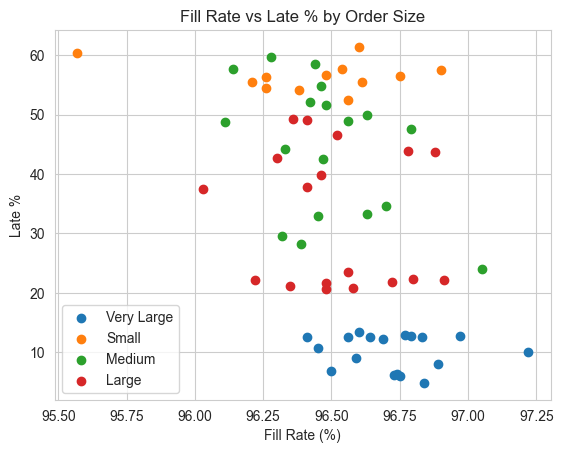

In [138]:
import matplotlib.pyplot as plt

sizes = df_detail['order_size_group'].unique()

plt.figure()

for size in sizes:
    subset = df_detail[df_detail['order_size_group'] == size]
    plt.scatter(subset['fill_rate'], subset['late_pct'], label=size)

plt.xlabel('Fill Rate (%)')
plt.ylabel('Late %')
plt.title('Fill Rate vs Late % by Order Size')
plt.legend()

plt.show()

In [112]:
df_size = df_detail.groupby('order_size_group').agg({
    'late_pct': 'mean',
    'fill_rate': 'mean',
    'total_order_lines': 'sum'
}).reset_index()

df_size

,order_size_group,late_pct,fill_rate,total_order_lines
0,Large,32.612222,96.513889,12458
1,Medium,44.405000,96.480556,10355
2,Small,56.530833,96.426667,8379
3,Very Large,10.131111,96.720556,25904


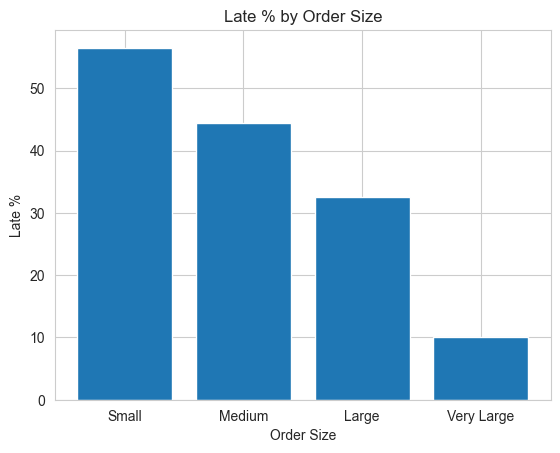

In [114]:
import matplotlib.pyplot as plt
order = ['Small', 'Medium', 'Large', 'Very Large']
df_size['order_size_group'] = pd.Categorical(df_size['order_size_group'], categories=order, ordered=True)
df_size = df_size.sort_values('order_size_group')
plt.figure()
plt.bar(df_size['order_size_group'], df_size['late_pct'])
plt.xlabel('Order Size')
plt.ylabel('Late %')
plt.title('Late % by Order Size')
plt.show()

In [121]:
df_small = df_detail[df_detail['order_size_group'] == 'Small']

In [122]:
top_late_product = df_small.sort_values('late_pct', ascending=False).head(10)

top_late_product[['product_name', 'category', 'late_pct', 'fill_rate', 'total_order_lines']]

,product_name,category,late_pct,fill_rate,total_order_lines
26,AM Butter 500,Dairy,61.40,96.60,228
18,AM Butter 250,Dairy,60.41,95.57,197
24,AM Tea 500,Beverages,57.62,96.54,899
29,AM Butter 100,Dairy,57.45,96.90,188
23,AM Ghee 150,Dairy,56.60,96.48,1228
28,AM Tea 100,Beverages,56.51,96.75,929
20,AM Tea 250,Beverages,56.28,96.26,899
27,AM Biscuits 500,Food,55.51,96.61,517
19,AM Ghee 250,Dairy,55.48,96.21,1168
21,AM Biscuits 250,Food,54.51,96.26,488


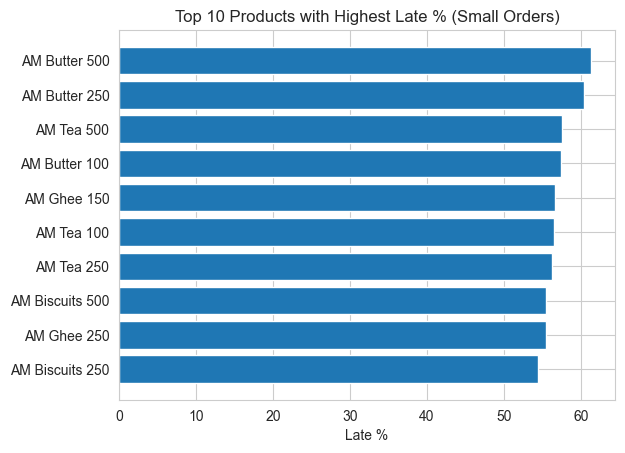

In [123]:
import matplotlib.pyplot as plt

top_late_product = df_small.sort_values('late_pct', ascending=False).head(10)

plt.figure()
plt.barh(top_late_product['product_name'], top_late_product['late_pct'])
plt.xlabel('Late %')
plt.title('Top 10 Products with Highest Late % (Small Orders)')
plt.gca().invert_yaxis()
plt.show()

In [125]:
pivot_product = df_detail.pivot_table(
    index='product_name',
    columns='order_size_group',
    values='late_pct'
)

pivot_product.head(10)

order_size_group,Large,Medium,Small,Very Large
product_name,,,,
AM Biscuits 250,21.63,47.57,54.51,9.00
AM Biscuits 500,21.85,44.29,55.51,10.67
AM Biscuits 750,22.11,42.53,52.47,9.99
AM Butter 100,37.86,49.92,57.45,12.99
AM Butter 250,37.48,48.78,60.41,12.53
AM Butter 500,39.89,48.94,61.40,12.62
AM Curd 100,43.74,52.07,NaN,12.57
AM Curd 250,43.90,51.61,NaN,12.67
AM Curd 50,42.72,54.90,NaN,12.55


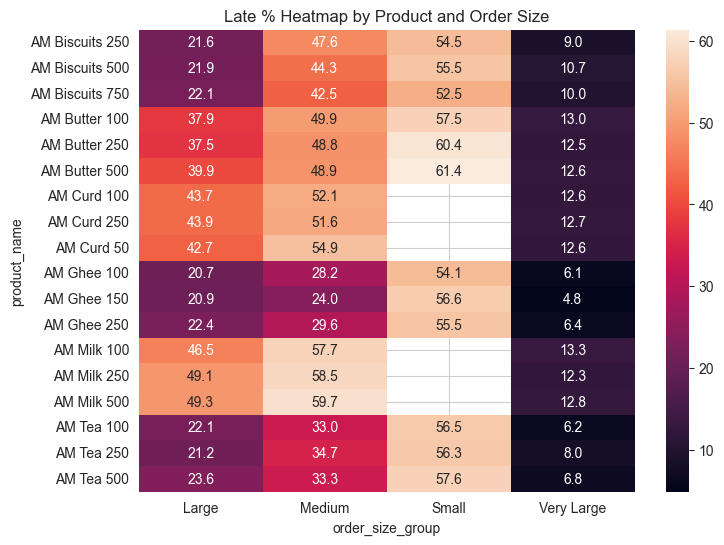

In [130]:
import seaborn as sns
import matplotlib.pyplot as plt

pivot = df_detail.pivot_table(
    index='product_name',
    columns='order_size_group',
    values='late_pct'
)

plt.figure(figsize=(8,6))
sns.heatmap(pivot, annot=True, fmt=".1f")
plt.title('Late % Heatmap by Product and Order Size')
plt.show()

In [139]:
query="""
WITH order_sizes AS (
    SELECT 
        order_id,
        NTILE(4) OVER (ORDER BY SUM(order_qty)) AS size_group_num
    FROM analytics.fact_order_lines
    GROUP BY order_id
),
labeled_orders AS (
    SELECT 
        order_id,
        CASE 
            WHEN size_group_num = 1 THEN 'Small'
            WHEN size_group_num = 2 THEN 'Medium'
            WHEN size_group_num = 3 THEN 'Large'
            WHEN size_group_num = 4 THEN 'Very Large'
        END AS order_size_group
    FROM order_sizes
)

SELECT 
    o.order_size_group,
    p.category,
    p.product_name,
    c.city,
    c.customer_name,
    COUNT(f.order_id) AS total_order_lines,
    ROUND(AVG(SAFE_DIVIDE(f.delivered_qty, f.order_qty)) * 100, 2) AS fill_rate,
    ROUND(COUNTIF(f.actual_delivery_date > f.agreed_delivery_date) / COUNT(f.order_id) * 100, 2) AS late_pct
FROM analytics.fact_order_lines f
JOIN labeled_orders o ON f.order_id = o.order_id
JOIN analytics.dim_products p ON f.product_id = p.product_id
JOIN analytics.dim_customers c ON f.customer_id = c.customer_id
GROUP BY 
    o.order_size_group, 
    p.category, 
    p.product_name,
    c.city,
    c.customer_name
ORDER BY 
    o.order_size_group DESC, 
    fill_rate ASC;
"""
df_detail = client.query(query).to_dataframe()
df_detail

,order_size_group,category,product_name,city,customer_name,total_order_lines,fill_rate,late_pct
0,Very Large,Dairy,AM Ghee 250,Vadodara,Coolblue,5,84.89,80.00
1,Very Large,Beverages,AM Tea 100,Ahmedabad,Lotus Mart,10,89.00,80.00
2,Very Large,Dairy,AM Curd 250,Surat,Acclaimed Stores,30,89.67,80.00
3,Very Large,Food,AM Biscuits 500,Ahmedabad,Lotus Mart,12,90.45,91.67
4,Very Large,Food,AM Biscuits 500,Surat,Acclaimed Stores,22,90.48,95.45
...,...,...,...,...,...,...,...,...
2304,Large,Dairy,AM Ghee 250,Vadodara,Expert Mart,12,100.00,8.33
2305,Large,Dairy,AM Ghee 150,Ahmedabad,Atlas Stores,9,100.00,11.11
2306,Large,Dairy,AM Ghee 100,Ahmedabad,Chiptec Stores,10,100.00,10.00
2307,Large,Food,AM Biscuits 750,Surat,Viveks Stores,9,100.00,0.00


In [140]:
df_small = df_detail[df_detail['order_size_group'] == 'Small']

city_perf = df_small.groupby('city').agg({
    'late_pct': 'mean',
    'fill_rate': 'mean',
    'total_order_lines': 'sum'
}).reset_index()

city_perf.sort_values('late_pct', ascending=False).head(10)

,city,late_pct,fill_rate,total_order_lines
2,Vadodara,55.065874,96.388042,2890
1,Surat,53.283788,96.707803,2520
0,Ahmedabad,51.556875,96.588542,2969


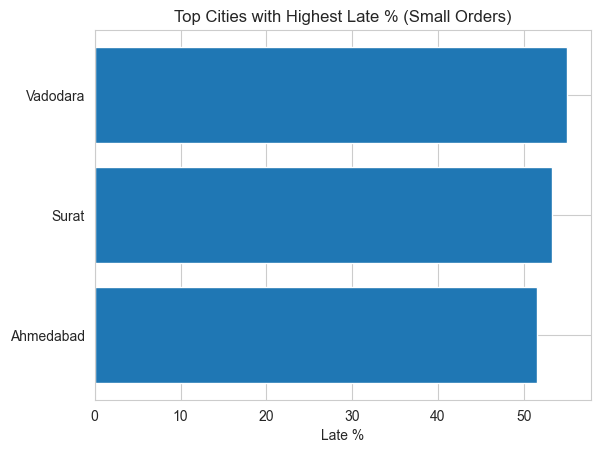

In [141]:
import matplotlib.pyplot as plt

top_city = city_perf.sort_values('late_pct', ascending=False).head(10)

plt.figure()
plt.barh(top_city['city'], top_city['late_pct'])
plt.xlabel('Late %')
plt.title('Top Cities with Highest Late % (Small Orders)')
plt.gca().invert_yaxis()
plt.show()

In [142]:
pivot_city = df_detail.pivot_table(
    index='city',
    columns='order_size_group',
    values='late_pct'
)

pivot_city.head()

order_size_group,Large,Medium,Small,Very Large
city,,,,
Ahmedabad,31.940509,42.140278,51.556875,21.635463
Surat,27.513384,40.127172,53.283788,16.261616
Vadodara,32.799167,41.762176,55.065874,21.743333


In [143]:
cus_perf = df_small.groupby('customer_name').agg({
    'late_pct': 'mean',
    'fill_rate': 'mean',
    'total_order_lines': 'sum'
}).reset_index()

cus_perf.sort_values('late_pct', ascending=False).head(10)

,customer_name,late_pct,fill_rate,total_order_lines
9,Lotus Mart,71.576111,96.065000,1161
3,Coolblue,68.750417,94.890000,803
0,Acclaimed Stores,68.155556,96.128333,1188
6,Expression Stores,52.500000,98.101667,429
7,Info Stores,52.475417,94.846250,390
14,Viveks Stores,50.681667,97.460417,378
10,Propel Mart,49.773333,97.377778,550
13,Vijay Stores,49.213333,95.475278,567
11,Rel Fresh,48.924167,97.633333,591
5,Expert Mart,48.496667,97.411667,366


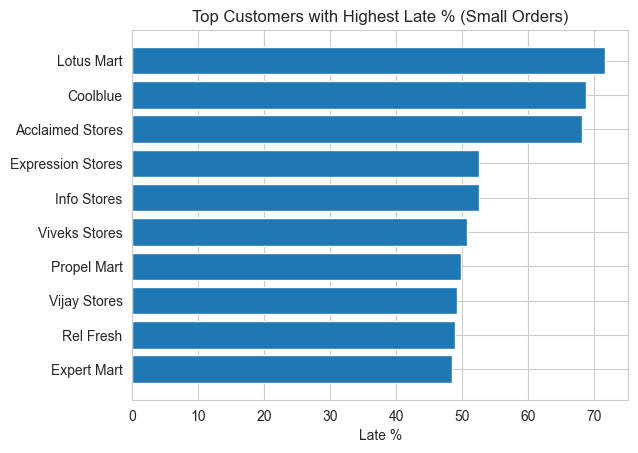

In [144]:
top_cus = cus_perf.sort_values('late_pct', ascending=False).head(10)

plt.figure()
plt.barh(top_cus['customer_name'], top_cus['late_pct'])
plt.xlabel('Late %')
plt.title('Top Customers with Highest Late % (Small Orders)')
plt.gca().invert_yaxis()
plt.show()

In [145]:
cus_perf.sort_values('total_order_lines', ascending=False).head(10)

,customer_name,late_pct,fill_rate,total_order_lines
0,Acclaimed Stores,68.155556,96.128333,1188
9,Lotus Mart,71.576111,96.065000,1161
3,Coolblue,68.750417,94.890000,803
11,Rel Fresh,48.924167,97.633333,591
13,Vijay Stores,49.213333,95.475278,567
10,Propel Mart,49.773333,97.377778,550
6,Expression Stores,52.500000,98.101667,429
1,Atlas Stores,45.283750,97.940000,416
8,Logic Stores,46.780417,97.706250,415
7,Info Stores,52.475417,94.846250,390


In [147]:
pivot_cus_city = df_small.pivot_table(
    index='customer_name',
    columns='city',
    values='late_pct'
)

pivot_cus_city.sort_values(by=pivot_cus_city.columns.tolist(), ascending=False).head(10)

city,Ahmedabad,Surat,Vadodara
customer_name,,,
Lotus Mart,72.732500,70.567500,71.428333
Acclaimed Stores,67.864167,67.474167,69.128333
Coolblue,67.504167,NaN,69.996667
Propel Mart,51.035000,51.275000,47.010000
Logic Stores,49.880000,43.680833,NaN
Sorefoz Mart,46.829167,NaN,45.641667
Rel Fresh,45.678333,47.809167,53.285000
Elite Mart,45.048333,NaN,46.746364
Vijay Stores,44.901667,59.075000,43.663333


In [149]:
query = """
WITH order_sizes AS (
    -- Phân loại Size cho từng Order
    SELECT 
        order_id,
        customer_id,
        NTILE(4) OVER (ORDER BY SUM(order_qty)) AS size_group_num
    FROM analytics.fact_order_lines
    GROUP BY order_id, customer_id
),
labeled_orders AS (
    SELECT 
        os.order_id,
        os.customer_id,
        CASE 
            WHEN size_group_num = 1 THEN 'Small'
            WHEN size_group_num = 2 THEN 'Medium'
            WHEN size_group_num = 3 THEN 'Large'
            WHEN size_group_num = 4 THEN 'Very Large'
        END AS order_size_group
    FROM order_sizes os
)
-- Tính tỷ trọng đơn Small của từng khách hàng
SELECT 
    c.customer_name,
    COUNT(lo.order_id) AS total_orders,
    COUNTIF(lo.order_size_group = 'Small') AS small_orders,
    ROUND(COUNTIF(lo.order_size_group = 'Small') / COUNT(lo.order_id) * 100, 2) AS small_pct
FROM labeled_orders lo
JOIN analytics.dim_customers c ON lo.customer_id = c.customer_id
GROUP BY c.customer_name
ORDER BY small_pct DESC
"""
customer_behavior_df = client.query(query).to_dataframe()
customer_behavior_df.head(10)

,customer_name,total_orders,small_orders,small_pct
0,Acclaimed Stores,3510,1124,32.02
1,Coolblue,2436,760,31.20
2,Lotus Mart,3550,1103,31.07
3,Expression Stores,1662,410,24.67
4,Atlas Stores,1646,391,23.75
5,Logic Stores,1676,389,23.21
6,Rel Fresh,2457,553,22.51
7,Info Stores,1669,372,22.29
8,Chiptec Stores,1642,361,21.99
9,Viveks Stores,1633,359,21.98


In [152]:
import plotly.express as px

# Cắt top 10 khách hàng có tỷ lệ đơn Small cao nhất
top_small_customers = customer_behavior_df.head(10)

fig = px.bar(
    top_small_customers,
    x='small_pct',
    y='customer_name',
    orientation='h',
    title='Pecentage of Small Oders by Customer',
    text='small_pct',
    labels={'small_pct': '% Small Orders', 'customer_name': 'Customer name'}
)
fig.update_traces(texttemplate='%{text:.1f}%', textposition='outside')
fig.show()